# Life Expectancy and Unemployment in Europe: A Data Science Analysis

## Introduction

This project explores the relationship between life expectancy and unemployment in European countries.

The analysis uses two independent public data sources:
1. WHO: Life expectancy at birth
2. Eurostat data on annual unemployment

The main goal is to examine whether higher unemployment is associated with lower life expectancy across European countries.

Markdown

## Data Sources

This project uses two independent public data sources:

1. WHO data on life expectancy at birth
2. Eurostat data on annual unemployment

The objective is to examine whether unemployment is associated with life expectancy across European countries.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [19]:
life_path = "../data/raw/life_expectancy_who.csv"
unemp_path = "../data/raw/unemployment_eurostat.csv"

In [20]:
print("Life expectancy file:", life_path)
print("Unemployment file:", unemp_path)

Life expectancy file: ../data/raw/life_expectancy_who.csv
Unemployment file: ../data/raw/unemployment_eurostat.csv


## Loading the Raw Data

The first step is to load the two datasets into pandas DataFrames so they can be inspected, cleaned, and prepared for analysis.

## Cleaning the Life Expectancy Data

The WHO dataset contains multiple indicators and categories. For this analysis, the data is filtered to keep only life expectancy at birth, European countries, both sexes, and yearly observations.

In [21]:
life_df = pd.read_csv(life_path)
life_df.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,IsLatestYear,Dim1 type,Dim1,Dim1ValueCode,Dim2 type,Dim2,Dim2ValueCode,Dim3 type,Dim3,Dim3ValueCode,DataSourceDimValueCode,DataSource,FactValueNumericPrefix,FactValueNumeric,FactValueUoM,FactValueNumericLowPrefix,FactValueNumericLow,FactValueNumericHighPrefix,FactValueNumericHigh,Value,FactValueTranslationID,FactComments,Language,DateModified
0,WHOSIS_000001,Life expectancy at birth (years),text,AFR,Africa,Country,LSO,Lesotho,Year,2021,True,Sex,Male,SEX_MLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.73,NaN,NaN,47.80,NaN,49.70,48.7 [47.8-49.7],NaN,NaN,EN,2024-08-01T23:00:00.000Z
1,WHOSIS_000001,Life expectancy at birth (years),text,AFR,Africa,Country,CAF,Central African Republic,Year,2021,True,Sex,Male,SEX_MLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.57,NaN,NaN,48.45,NaN,50.92,49.6 [48.5-50.9],NaN,NaN,EN,2024-08-01T23:00:00.000Z
2,WHOSIS_000001,Life expectancy at birth (years),text,AFR,Africa,Country,LSO,Lesotho,Year,2021,True,Sex,Both sexes,SEX_BTSX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.48,NaN,NaN,50.49,NaN,52.57,51.5 [50.5-52.6],NaN,NaN,EN,2024-08-01T23:00:00.000Z
3,WHOSIS_000001,Life expectancy at birth (years),text,AFR,Africa,Country,SWZ,Eswatini,Year,2021,True,Sex,Male,SEX_MLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.64,NaN,NaN,50.73,NaN,52.82,51.6 [50.7-52.8],NaN,NaN,EN,2024-08-01T23:00:00.000Z
4,WHOSIS_000001,Life expectancy at birth (years),text,EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,True,Sex,Male,SEX_MLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.75,NaN,NaN,50.62,NaN,53.10,51.7 [50.6-53.1],NaN,NaN,EN,2024-08-01T23:00:00.000Z


In [22]:
unemp_df = pd.read_csv(unemp_path)
unemp_df.head()

,DATAFLOW,LAST UPDATE,freq,sex,age,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:TIPSUN20(1.0),12/03/26 23:00:00,A,T,Y15-24,PC_ACT,AT,2009,11.3,NaN,NaN
1,ESTAT:TIPSUN20(1.0),12/03/26 23:00:00,A,T,Y15-24,PC_ACT,AT,2010,10.1,NaN,NaN
2,ESTAT:TIPSUN20(1.0),12/03/26 23:00:00,A,T,Y15-24,PC_ACT,AT,2011,9.5,NaN,NaN
3,ESTAT:TIPSUN20(1.0),12/03/26 23:00:00,A,T,Y15-24,PC_ACT,AT,2012,10.0,NaN,NaN
4,ESTAT:TIPSUN20(1.0),12/03/26 23:00:00,A,T,Y15-24,PC_ACT,AT,2013,10.3,NaN,NaN


In [23]:
life_birth = life_df[
    (life_df["Indicator"] == "Life expectancy at birth (years)") &
    (life_df["ParentLocation"] == "Europe") &
    (life_df["Dim1"] == "Both sexes")
].copy()

life_birth = life_birth[["Location", "Period", "FactValueNumeric"]].copy()

life_birth = life_birth.rename(columns={
    "Location": "country",
    "Period": "year",
    "FactValueNumeric": "life_expectancy"
})

life_birth["year"] = pd.to_numeric(life_birth["year"], errors="coerce")
life_birth["life_expectancy"] = pd.to_numeric(life_birth["life_expectancy"], errors="coerce")

life_birth = life_birth.dropna().sort_values(["country", "year"])

life_birth.head(10)

,country,year,life_expectancy
23686,Albania,2000,73.68
22634,Albania,2001,76.04
21501,Albania,2002,75.49
20371,Albania,2003,74.94
19268,Albania,2004,75.43
18126,Albania,2005,74.21
17008,Albania,2006,74.22
15900,Albania,2007,74.54
14796,Albania,2008,74.99
13691,Albania,2009,75.56


In [24]:
print(life_birth.shape)
print(life_birth["country"].nunique())
print(life_birth["year"].min(), life_birth["year"].max())
print(life_birth["country"].unique()[:20])

(1100, 3)
50
2000 2021
['Albania' 'Armenia' 'Austria' 'Azerbaijan' 'Belarus' 'Belgium'
 'Bosnia and Herzegovina' 'Bulgaria' 'Croatia' 'Cyprus' 'Czechia'
 'Denmark' 'Estonia' 'Finland' 'France' 'Georgia' 'Germany' 'Greece'
 'Hungary' 'Iceland']


In [25]:
unemp_clean = unemp_df[
    (unemp_df["freq"] == "A") &
    (unemp_df["sex"] == "T") &
    (unemp_df["age"] == "Y15-74") &
    (unemp_df["unit"] == "PC_ACT")
].copy()

unemp_clean = unemp_clean[["geo", "TIME_PERIOD", "OBS_VALUE"]].copy()

unemp_clean = unemp_clean.rename(columns={
    "geo": "geo_code",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "unemployment_rate"
})

unemp_clean["year"] = pd.to_numeric(unemp_clean["year"], errors="coerce")
unemp_clean["unemployment_rate"] = pd.to_numeric(unemp_clean["unemployment_rate"], errors="coerce")

unemp_clean = unemp_clean.dropna()

# keep only 2-letter country codes, remove aggregates like EU27_2020 and EA20
unemp_clean = unemp_clean[unemp_clean["geo_code"].str.len() == 2]

unemp_clean = unemp_clean.sort_values(["geo_code", "year"])

unemp_clean.head(10)

,geo_code,year,unemployment_rate
520,AT,2009,5.7
521,AT,2010,5.2
522,AT,2011,4.9
523,AT,2012,5.2
524,AT,2013,5.7
525,AT,2014,6.0
526,AT,2015,6.1
527,AT,2016,6.5
528,AT,2017,5.9
529,AT,2018,5.2


## Cleaning the Unemployment Data

The Eurostat dataset is filtered to keep only annual observations, total unemployment, age group 15–74, and percentage of active population. Aggregate regions such as EU totals are removed.

In [26]:
print(unemp_clean.shape)
print(unemp_clean["geo_code"].nunique())
print(unemp_clean["year"].min(), unemp_clean["year"].max())
print(unemp_clean["geo_code"].unique()[:20])

(469, 3)
27
2003 2025
['AT' 'BE' 'BG' 'CY' 'CZ' 'DE' 'DK' 'EE' 'EL' 'ES' 'FI' 'FR' 'HR' 'HU'
 'IE' 'IT' 'LT' 'LU' 'LV' 'MT']


## Matching Countries for Merging

The WHO dataset uses country names, while the Eurostat dataset uses two-letter country codes. A mapping is created so the two datasets can be merged correctly.

In [27]:
country_to_code = {
    "Austria": "AT",
    "Belgium": "BE",
    "Bulgaria": "BG",
    "Croatia": "HR",
    "Cyprus": "CY",
    "Czechia": "CZ",
    "Denmark": "DK",
    "Estonia": "EE",
    "Finland": "FI",
    "France": "FR",
    "Germany": "DE",
    "Greece": "EL",
    "Hungary": "HU",
    "Ireland": "IE",
    "Italy": "IT",
    "Latvia": "LV",
    "Lithuania": "LT",
    "Luxembourg": "LU",
    "Malta": "MT",
    "Netherlands (Kingdom of the)": "NL",
    "Poland": "PL",
    "Portugal": "PT",
    "Romania": "RO",
    "Slovakia": "SK",
    "Slovenia": "SI",
    "Spain": "ES",
    "Sweden": "SE"
}

life_birth["geo_code"] = life_birth["country"].map(country_to_code)

life_eu = life_birth.dropna(subset=["geo_code"]).copy()

life_eu.head(10)

,country,year,life_expectancy,geo_code
23808,Austria,2000,78.18,AT
22700,Austria,2001,78.64,AT
21591,Austria,2002,78.70,AT
20472,Austria,2003,78.63,AT
19369,Austria,2004,79.11,AT
18257,Austria,2005,79.33,AT
17151,Austria,2006,79.81,AT
16036,Austria,2007,80.03,AT
14933,Austria,2008,80.27,AT
13816,Austria,2009,80.12,AT


In [28]:
print(life_eu.shape)
print(life_eu["country"].nunique())
print(sorted(life_eu["geo_code"].unique()))

(594, 4)
27
['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']


## Merging the Datasets

The two cleaned datasets are merged by country code and year. The resulting dataset contains both life expectancy and unemployment rate for the same country and year.

In [29]:
merged_df = pd.merge(
    life_eu,
    unemp_clean,
    on=["geo_code", "year"],
    how="inner"
)

merged_df = merged_df[[
    "country",
    "geo_code",
    "year",
    "life_expectancy",
    "unemployment_rate"
]].sort_values(["country", "year"])

merged_df.head(10)

,country,geo_code,year,life_expectancy,unemployment_rate
0,Austria,AT,2009,80.12,5.7
1,Austria,AT,2010,80.39,5.2
2,Austria,AT,2011,80.74,4.9
3,Austria,AT,2012,80.72,5.2
4,Austria,AT,2013,80.91,5.7
5,Austria,AT,2014,81.24,6.0
6,Austria,AT,2015,80.99,6.1
7,Austria,AT,2016,81.39,6.5
8,Austria,AT,2017,81.39,5.9
9,Austria,AT,2018,81.42,5.2


In [30]:
print(merged_df.shape)
print(merged_df["country"].nunique())
print(merged_df["year"].min(), merged_df["year"].max())

(361, 5)
27
2003 2021




## Descriptive Statistics

After cleaning and merging the two datasets, the next step is to explore the main numerical characteristics of the data.

This section summarizes the central tendency and spread of life expectancy and unemployment rate across the merged observations.

In [32]:
merged_df[["life_expectancy", "unemployment_rate"]].describe()

,life_expectancy,unemployment_rate
count,361.000000,361.000000
mean,79.294654,8.977008
std,2.827511,4.536463
min,71.310000,2.000000
25%,77.090000,6.000000
50%,80.530000,7.900000
75%,81.420000,10.600000
max,83.140000,27.800000


In [33]:
print("Number of rows:", len(merged_df))
print("Number of countries:", merged_df["country"].nunique())
print("Years covered:", merged_df["year"].min(), "-", merged_df["year"].max())

print("\nAverage life expectancy:", round(merged_df["life_expectancy"].mean(), 2))
print("Median life expectancy:", round(merged_df["life_expectancy"].median(), 2))
print("Minimum life expectancy:", round(merged_df["life_expectancy"].min(), 2))
print("Maximum life expectancy:", round(merged_df["life_expectancy"].max(), 2))

print("\nAverage unemployment rate:", round(merged_df["unemployment_rate"].mean(), 2))
print("Median unemployment rate:", round(merged_df["unemployment_rate"].median(), 2))
print("Minimum unemployment rate:", round(merged_df["unemployment_rate"].min(), 2))
print("Maximum unemployment rate:", round(merged_df["unemployment_rate"].max(), 2))

Number of rows: 361
Number of countries: 27
Years covered: 2003 - 2021

Average life expectancy: 79.29
Median life expectancy: 80.53
Minimum life expectancy: 71.31
Maximum life expectancy: 83.14

Average unemployment rate: 8.98
Median unemployment rate: 7.9
Minimum unemployment rate: 2.0
Maximum unemployment rate: 27.8


Markdown

The merged dataset contains annual observations for 27 EU countries between 2003 and 2021.

Life expectancy is generally high across the dataset, while unemployment shows a wider spread. This suggests that unemployment varies more strongly across countries and years than life expectancy.

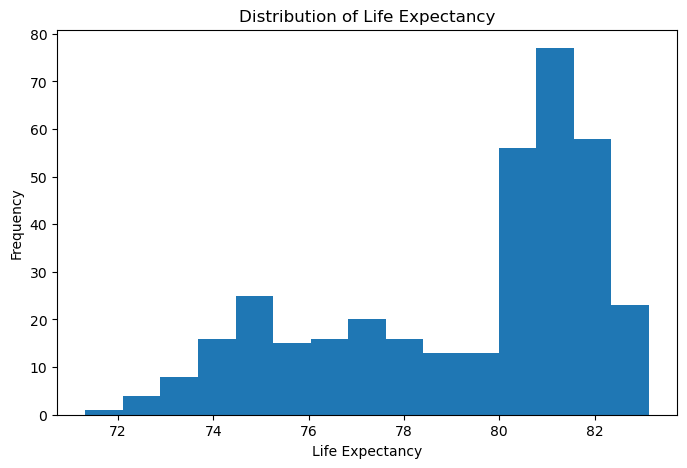

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(merged_df["life_expectancy"], bins=15)
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.title("Distribution of Life Expectancy")
plt.show()

## Interpretation

The histogram shows that most life expectancy values are concentrated in the higher range. This indicates that EU countries generally have relatively high life expectancy, with fewer observations at the lower end.

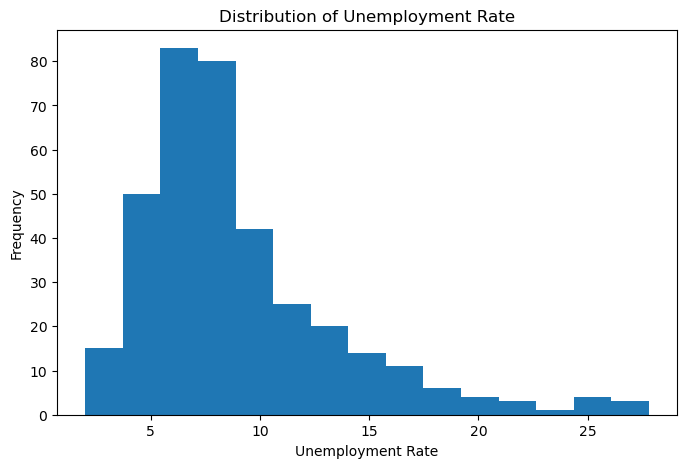

In [35]:
plt.figure(figsize=(8, 5))
plt.hist(merged_df["unemployment_rate"], bins=15)
plt.xlabel("Unemployment Rate")
plt.ylabel("Frequency")
plt.title("Distribution of Unemployment Rate")
plt.show()

## Interpretation

The unemployment distribution is more spread out than life expectancy. This suggests stronger variation in unemployment across countries and over time.



## Relationship Between Life Expectancy and Unemployment

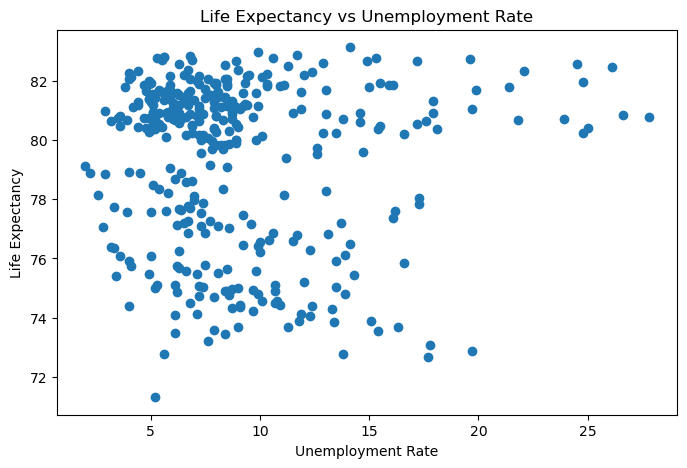

In [37]:
plt.figure(figsize=(8, 5))
plt.scatter(merged_df["unemployment_rate"], merged_df["life_expectancy"])
plt.xlabel("Unemployment Rate")
plt.ylabel("Life Expectancy")
plt.title("Life Expectancy vs Unemployment Rate")
plt.show()

In [38]:
correlation = merged_df["life_expectancy"].corr(merged_df["unemployment_rate"])
print("Correlation:", round(correlation, 3))

Correlation: -0.023


## Interpretation

The scatter plot does not show a strong visible linear relationship between unemployment and life expectancy. The correlation coefficient is -0.023, which indicates an extremely weak negative linear association in the merged dataset.

This suggests that unemployment alone does not explain much of the variation in life expectancy across EU countries and years. Other social, economic, and healthcare factors are also likely to play an important role.

## Limitations

This analysis has several limitations. First, correlation does not imply causation, so the results do not prove that unemployment causes changes in life expectancy. Second, the project uses only two variables, while life expectancy is affected by many other factors such as healthcare quality, income, education, and public policy. Third, the analysis combines countries and years together, which may hide country-specific patterns.

A future extension of the project could include more explanatory variables and separate country-level or time-based analysis.

## Conclusion

This project explored the relationship between life expectancy and unemployment across 27 EU countries between 2003 and 2021 using data from WHO and Eurostat.

After cleaning and merging the datasets, the analysis showed that life expectancy is generally high across EU countries, while unemployment varies more widely across countries and years. The correlation between unemployment and life expectancy was very weak and slightly negative (-0.023).

This suggests that there is no strong linear relationship between the two variables in this dataset. Although unemployment may still matter in specific contexts, life expectancy is influenced by many additional factors such as healthcare access, income, education, and living conditions.

Overall, the project demonstrates how two independent datasets can be cleaned, matched, merged, and analyzed in order to study a real-world question using data science methods.